In [271]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib
import numpy as np
from scipy.optimize import fmin_cobyla
from eos_code import *

In [272]:
data = np.loadtxt('data.txt')
degree = 3
n_test = 50
constraints=1   #  1 for constrained EOS GP and 0 for unconstrained EOS GP

In [273]:

X = data[:,0:2]                                     # input Volume-Temperature
y1 = data[:,2].reshape(-1,1)                        # output pressure
y2 = data[:,3].reshape(-1,1)                        # output energy
y3 = y2 + 8.9431 + 0.5 * (X[:,0].reshape(-1,1) - 5.6648) * (y1 + 12)*((1e-2)/1.6)       # Hugoniot


In [274]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)


scaler1 = MinMaxScaler()
y_norm = scaler1.fit_transform(np.hstack((y1,y2)))
y = np.concatenate((y_norm[:,0], y_norm[:,1]))
y = y.reshape(-1,1)

scaler2 = MinMaxScaler()
H = scaler2.fit_transform(y3)


In [275]:
X_test,_ = test(X, n_test = 50)                # test points
X_c,_  = test(X, n_test = 10)                   # virtual points

In [276]:
mu_regression, mu_test_regression = poly_regression(X, y, X_test, n_test, degree)

In [277]:


class GP_EOS:
    def __init__(self, X, y, mu_regression, X_c, n_test, degree):
        self.X = X
        self.y = y
        self.mu_regression = mu_regression
        self.X_c = X_c
        self.n_test = n_test
        self.degree = degree

    def neglikelihood(self, theta):
        return mle(theta, self.X, self.y, self.mu_regression, constraints)

    def predict_virtual(self, theta):
        return predict_prime(theta, self.X, self.y, self.X_c, self.n_test, self.degree, constraints)

    def nonneg_const(self, theta):
        yy, s = self.predict_virtual(theta)
        y_prime_mean_P = yy[:self.X_c.shape[0]]
        y_prime_std_P = s[:self.X_c.shape[0]]

        y_prime_mean_E = yy[self.X_c.shape[0]:]
        y_prime_std_E = s[self.X_c.shape[0]:]

        const1 = y_prime_mean_P + 1.96 * np.sqrt(y_prime_std_P)
        const2 = y_prime_mean_E - 1.96 * np.sqrt(y_prime_std_E)

        const = np.concatenate((-const1, const2))

        return const

    def optimize(self, constraints):
        if constraints == 1:
            cons = self.nonneg_const
        else:
            cons = []

        n = 10
        lb = np.array([-3.0, -3.0, -3.0, -10.0, -10.0])
        r = np.random.standard_normal(size=(n, 5))
        x0 = r + lb
        optipar = np.zeros((n, 5))
        optifun = np.zeros((n, 1))

        for i in range(n):
            print(i)
            res = fmin_cobyla(self.neglikelihood, x0[i, :].T, cons=cons, args=(),
                              consargs=None, rhobeg=1.0, rhoend=0.0001, maxfun=1000,
                              disp=True, catol=0.0002)
            optipar[i, :] = res
            print(optipar[i, :])
            optifun[i, :] = self.neglikelihood(res)
            print(optifun[i, :])

        theta = optipar[np.argmin(optifun)]

        return theta


In [278]:
optimizer = GP_EOS(X, y, mu_regression, X_c, n_test, degree)
thetaopt = optimizer.optimize(constraints)

0
[ -0.89452862  -1.1977472   -3.34453908  -9.6568971  -10.48991544]
   Normal return from subroutine COBYLA

   NFVALS =  110   F =-1.764930E+02    MAXCV = 1.682747E-09
   X =-8.945286E-01  -1.197747E+00  -3.344539E+00  -9.656897E+00  -1.048992E+01

[-176.49304891]
1
[ -0.89448002  -1.19780277  -3.34464868 -11.12888371  -7.48244644]
   Normal return from subroutine COBYLA

   NFVALS =   96   F =-1.764930E+02    MAXCV = 1.498060E-09
   X =-8.944800E-01  -1.197803E+00  -3.344649E+00  -1.112888E+01  -7.482446E+00

[-176.49304864]
2
[ -0.89452662  -1.19768513  -3.34441664 -10.88011246 -10.0441341 ]
   Normal return from subroutine COBYLA

   NFVALS =  105   F =-1.764930E+02    MAXCV = 4.285788E-09
   X =-8.945266E-01  -1.197685E+00  -3.344417E+00  -1.088011E+01  -1.004413E+01

[-176.49304525]
3
[ -0.89457423  -1.1977132   -3.344472   -11.07517272  -8.87588084]
   Normal return from subroutine COBYLA

   NFVALS =  174   F =-1.764930E+02    MAXCV = 4.702427E-10
   X =-8.945742E-01  -1.19771

In [279]:
y_pred, y_std = predict(thetaopt, X, y, X_test, n_test, degree, constraints)

In [280]:
X_testP, X_testE = test(X, n_test=50)          # test points

In [281]:
y_pred_P_prime, y_varr_P_prime = predict_prime(thetaopt, X, y, X_testP, n_test, degree, constraints)
y_pred_E_prime, y_varr_E_prime = predict_prime(thetaopt, X, y, X_testE, n_test, degree, constraints)

In [282]:
consP = y_pred_P_prime[:X_testP.shape[0]] + 1.96*np.sqrt(y_varr_P_prime[:X_testP.shape[0]])
consE = y_pred_E_prime[X_testE.shape[0]:] - 1.96*np.sqrt(y_varr_E_prime[X_testE.shape[0]:])
consP[consP>0].size, consE[consE<0].size

(0, 1)

In [283]:
y11 = y_pred[:X_test.shape[0]].reshape(-1,1)
y22 = y_pred[X_test.shape[0]:].reshape(-1,1)
y33 = y_std[:X_test.shape[0]].reshape(-1,1)
y44 = y_std[X_test.shape[0]:].reshape(-1,1)

In [284]:
y_mean = np.hstack((y11,y22))
y_ub = np.hstack((y11+y33, y22+y44))
y_lb = np.hstack((y11-y33, y22-y44))

In [285]:

y_mean1 = scaler1.inverse_transform(y_mean)
y_ub1 = scaler1.inverse_transform(y_ub)
y_lb1 = scaler1.inverse_transform(y_lb)
y_std1 = y_mean1 - y_lb1
y_std2 = y_ub1 - y_mean1

In [286]:
meanP = y_mean1[:,0]
meanE = y_mean1[:,1]
stdP =  y_std1[:,0]
stdE =  y_std1[:,1]

In [287]:
X_testP = scaler.inverse_transform(X_testP)
X_testE = scaler.inverse_transform(X_testE)

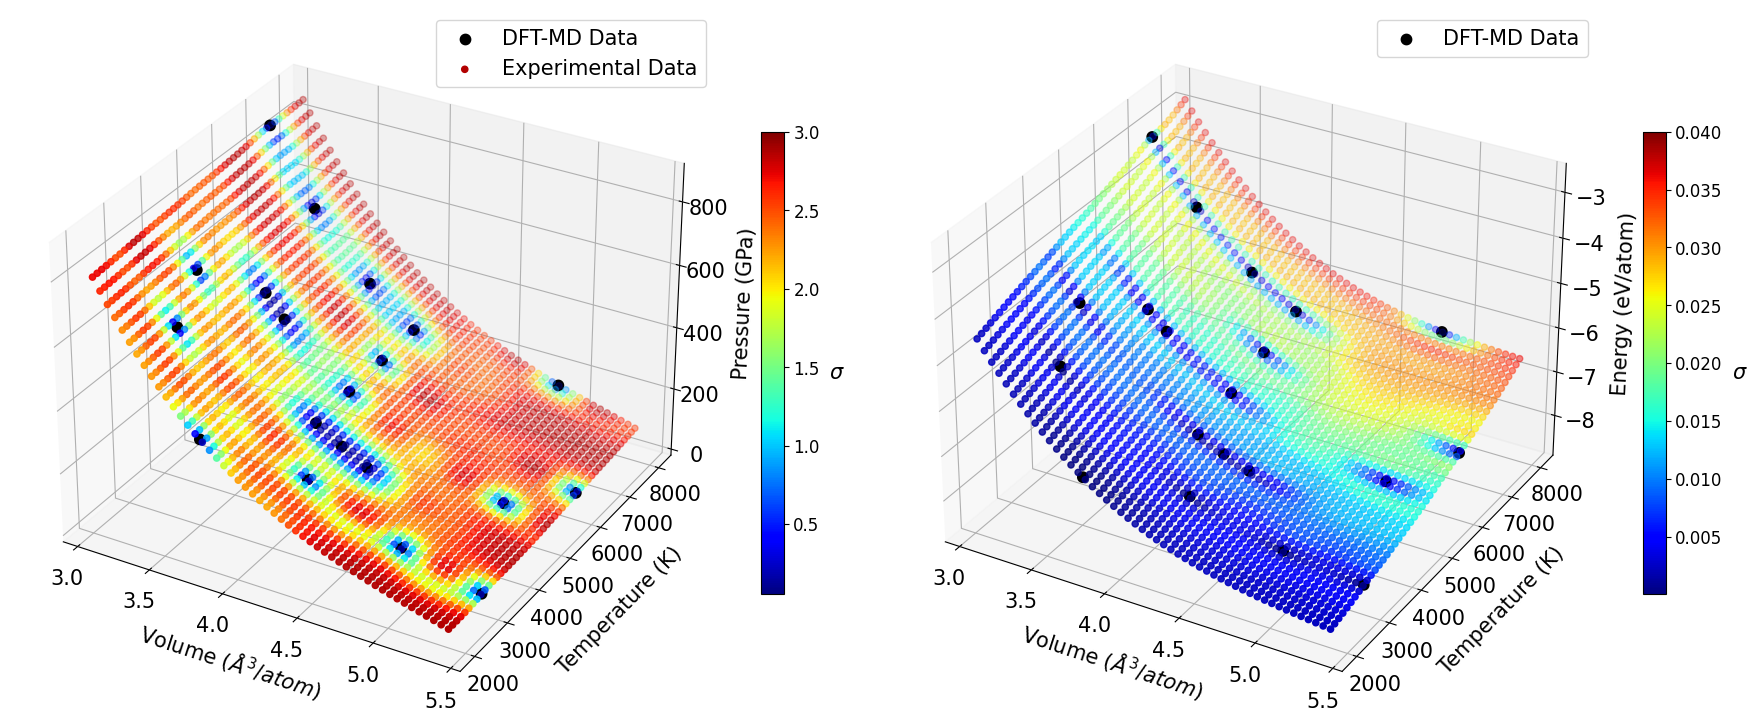

In [288]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(121, projection='3d')
p1 = ax1.scatter(data[:, 0], data[:, 1], data[:, 2], alpha=1, marker="o", color="k", linewidths=4, label="Simulation Data")
p0 = ax1.scatter(X_testP[:, 0], X_testP[:, 1], meanP, c=stdP, cmap=plt.cm.jet, vmax=3)
ax1.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=15, labelpad=8)
ax1.set_ylabel('Temperature (K)', fontsize=15, labelpad=12)
ax1.set_zlabel('Pressure (GPa)', fontsize=15, labelpad=9)
ax1.legend(['DFT-MD Data', 'Experimental Data'], loc='upper right', fontsize=15)
cbar1 = fig.colorbar(p0, ax=ax1, shrink=0.6)
cbar1.set_label(r'$\sigma$', rotation=0, fontsize=15, labelpad=12)
cbar1.ax.tick_params(labelsize=12)

ax2 = fig.add_subplot(122, projection='3d')
p = ax2.scatter(data[:, 0], data[:, 1], y2, alpha=1, marker="o", color="k", linewidths=4, label="Data")
p0 = ax2.scatter(X_testP[:, 0], X_testP[:, 1], meanE, c=stdE, cmap=plt.cm.jet, vmax=0.04)
ax2.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=15, labelpad=8)
ax2.set_ylabel('Temperature (K)', fontsize=15, labelpad=12)
ax2.set_zlabel('Energy (eV/atom)', fontsize=15, labelpad=8)
ax2.legend(['DFT-MD Data'], loc='upper right', fontsize=15)
cbar2 = fig.colorbar(p0, ax=ax2, shrink=0.6)
cbar2.set_label(r'$\sigma$', rotation=0, fontsize=15, labelpad=12)
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


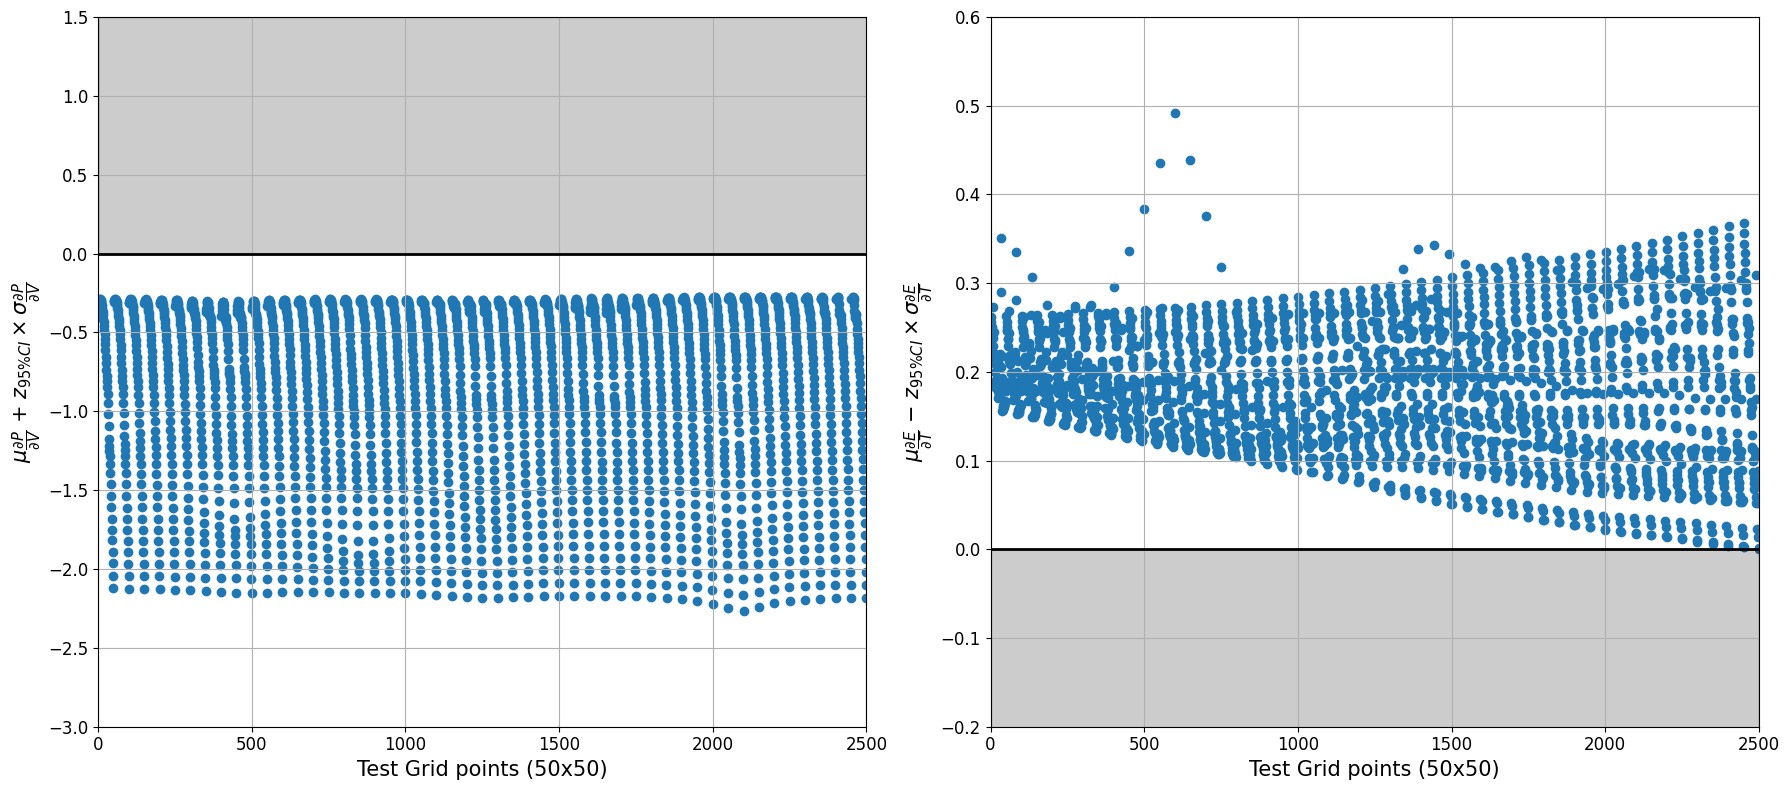

In [289]:

t = np.linspace(1,2500,2500, dtype=int)
plt.figure(figsize=(18, 8))

plt.subplot(121)
plt.scatter(t, consP)
plt.axhline(y=0, color='k', linewidth=2)
plt.ylabel(r'$\mu_{\dfrac{\partial P}{\partial V}}$ $+$ $z_{95\% CI} \times \sigma_{\dfrac{\partial P}{\partial V}}$', fontsize=15)
plt.xlabel('Test Grid points (50x50)', fontsize=15)
plt.xlim((0, 2500))
plt.ylim((-3, 1.5))
plt.tick_params(labelsize=12)
plt.fill_between(t, y1=0, y2=1.5, color='black', alpha=0.2)
plt.grid()

 
plt.subplot(122)
plt.scatter(t, consE)
plt.axhline(y=0, color='k', linewidth=2)
plt.ylabel(r'$\mu_{\dfrac{\partial E}{\partial T}}$ $-$ $z_{95\% CI} \times \sigma_{\dfrac{\partial E}{\partial T}}$', fontsize=15)
plt.xlabel('Test Grid points (50x50)', fontsize=15)
plt.xlim((0, 2500))
plt.ylim((-0.20, 0.6))
plt.tick_params(labelsize=12)
plt.fill_between(t, y1=0, y2=-0.6, color='black', alpha=0.2)
plt.grid()

plt.tight_layout()
plt.show()


In [290]:
def K11_H(x1, x2, l1, l2, sigma_f, sigma_n1):
    theta = np.array([1 / (2 * l1**2), 1 / (2 * l2**2)])
    diff_x1 = x1[:, 0] - 1.1182
    diff_x2 = x2[:, 0] - 1.1182
    exp_term = np.exp(-theta[0] * (np.subtract.outer(x1[:, 0], x2[:, 0])**2) - theta[1] * (np.subtract.outer(x1[:, 1], x2[:, 1])**2))
    K = 0.25 * np.outer(diff_x1, diff_x2) * (sigma_f**2 * exp_term) * (2 * theta[0] - 4 * theta[0]**2 * np.subtract.outer(x1[:, 0], x2[:, 0])**2)
    np.fill_diagonal(K, np.diag(K) + (sigma_n1**2))
    return K

In [291]:

def K22_H(x1, x2, l1, l2, sigma_f, sigma_n2):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    exp_term = np.exp(-np.sum(theta * sq_diff_x, axis=2))

    K = sigma_f**2 * (exp_term +
                      x1[:, 1][:, None] * exp_term * (2 * theta[1] * (x1[:, 1][:, None] - x2[:, 1][None, :])) +
                      x2[:, 1][None, :] * exp_term * (2 * theta[1] * (-x1[:, 1][:, None] + x2[:, 1][None, :])) +
                      x1[:, 1][:, None] * x2[:, 1][None, :] * exp_term * (2 * theta[1] - 4 * theta[1]**2 * sq_diff_x[:,:,1]))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n2)**2

In [292]:
def K12_H(x1, x2, l1, l2, sigma_f):
    theta = np.array([1 / (2 * l1**2), 1 / (2 * l2**2)])
    
    diff = x1[:, np.newaxis, :] - x2[np.newaxis, :, :]
    exp_term = np.exp(-np.sum(theta * diff**2, axis=2))
    
    K = (x2[:, 0] - 1.1182) * (
        sigma_f**2 * exp_term * 2 * theta[0] * diff[:, :, 0] -
        x2[:, 1] * sigma_f**2 * exp_term * 4 * theta[0] * theta[1] * diff[:, :, 0] * diff[:, :, 1]
    )
    
    return K

In [293]:
meanH_unscaled = (meanE + 8.9431) + 0.5 * (X_testP[:,0] - 5.6648) * (meanP + 12)*((1e-2)/1.6)
meanH = scaler2.transform(meanH_unscaled.reshape(-1,1))

In [294]:
l1, l2, s, sigma_n1, sigma_n2 = thetaopt

In [295]:
K_H = K11_H(X_test,X_test,10**l1,10**l2, 10**s, 10**sigma_n1) + K22_H(X_test,X_test,10**l1,10**l2,10**s, 10**sigma_n2) + K12_H(X_test,X_test,10**l1,10**l2,10**s)

In [296]:
stdH = np.sqrt(np.diag(K_H))

In [297]:
H_ub = scaler2.inverse_transform(meanH + stdH.reshape(-1,1))
H_std = H_ub - meanH_unscaled.reshape(-1,1)


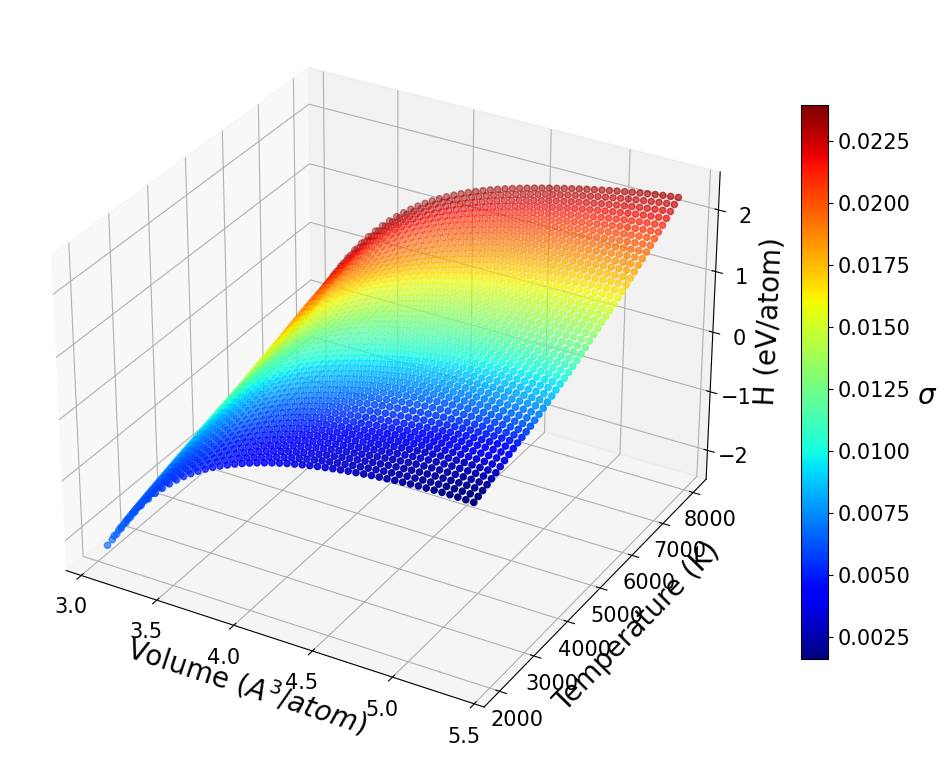

In [298]:

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p0 = ax.scatter(X_testP[:,0], X_testP[:,1], meanH_unscaled ,c= H_std, cmap=plt.cm.jet)
# p1 = ax.scatter(hugo[:,0], hugo[:,1], hugo[:,2])
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
# matplotlib.rc('ztick', labelsize=20)
ax.set_xlabel(r'Volume ($A^{3}/atom$)', fontsize=20 )
ax.set_ylabel('Temperature (K)', fontsize=20)
ax.set_zlabel(r'H (eV/atom)',fontsize=20)

cbar = fig.colorbar(p0, ax=ax, shrink=0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad=12)
cbar.ax.tick_params(labelsize=15)
plt.show()

In [299]:
stackd = np.hstack((X_testP, meanH_unscaled.reshape(-1,1), H_std.reshape(-1,1)))

In [300]:
H_cond = np.abs(stackd[:,2])<=1.96*stackd[:,3]


In [301]:
hugo_points = stackd[H_cond]


In [302]:
df = pd.read_excel('hugo_points.xlsx')                  # fine mesh
hugo = df.to_numpy()                                

In [303]:
df = pd.read_excel('hugo100.xlsx')                      # V,T mesh (100 X 100)
hugon = df.to_numpy()

In [304]:
H_cond_ub = np.logical_and(1.8*hugo[:,3] <= hugo[:,2], hugo[:,2] <= 1.96*hugo[:,3])
H_cond_lb = np.logical_and(-1.96*hugo[:,3] <= hugo[:,2], hugo[:,2] <= -1.8*hugo[:,3])

In [305]:
hugo_ub = hugo[H_cond_ub]
hugo_lb = hugo[H_cond_lb]

In [306]:

ind1 = np.argsort(hugo_ub[:,0])
H_upper = hugo_ub[ind1]
ind2 = np.argsort(hugo_lb[:,0])
H_lower = hugo_lb[ind2]


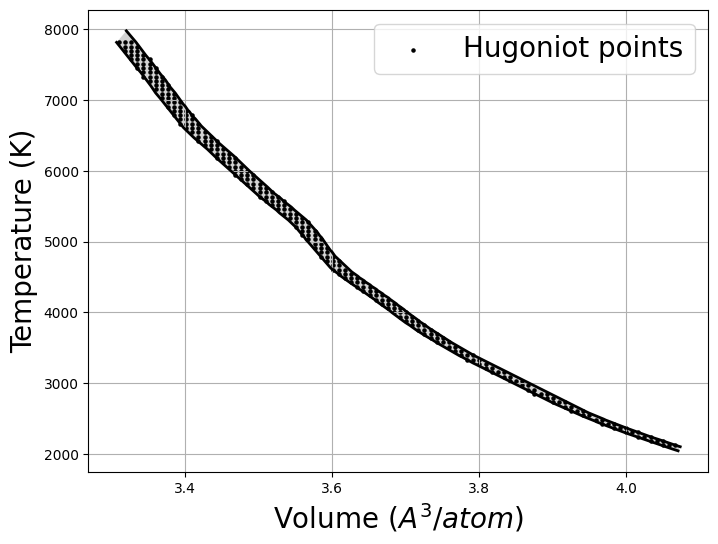

In [307]:
fig = plt.figure(figsize=(8,6))
plt.plot(H_upper[:,0], H_upper[:,1], color = 'k', linewidth = 2)
plt.plot(H_lower[:,0], H_lower[:,1], linewidth = 2, color ='k')
plt.fill(np.append(H_upper[:,0], H_lower[:,0][::-1]), np.append(H_upper[:,1], H_lower[:,1][::-1]), 'lightgrey')
p = plt.scatter(hugon[6:287,0], hugon[6:287,1], color = 'k',s = 5, label='Hugoniot points')
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
plt.xlabel(r'Volume ($A^{3}/atom$)', fontsize=20 )
plt.ylabel('Temperature (K)', fontsize=20)
plt.legend([p],['Hugoniot points'], loc='upper right', fontsize =20)
plt.grid()

In [308]:
    
poly = PolynomialFeatures(degree=4)
a = (1/12.011)*6.023*0.1

v = np.array([4.74, 5.77, 5.0])
vol_exp = (v*a)**(-1)
# testpoints= np.linspace(hugon[:,0].min(), hugon[:,0].max(),100) 
    
poly_traina = poly.fit_transform(hugon[:,0].reshape(-1,1))
# poly_testa = poly.fit_transform(testpoints.reshape(-1,1))
    
reg = LinearRegression().fit(poly_traina, hugon[:,1])

exptestV = poly.fit_transform(vol_exp.reshape(-1,1))
    
# mu_test = reg.predict(poly_testa)
exptestT = reg.predict(exptestV) 


In [309]:
vol_exp

array([4.20714967, 3.45613335, 3.98837788])

In [310]:
exptestT

array([1677.4818324 , 6191.47299911, 2373.53608845])

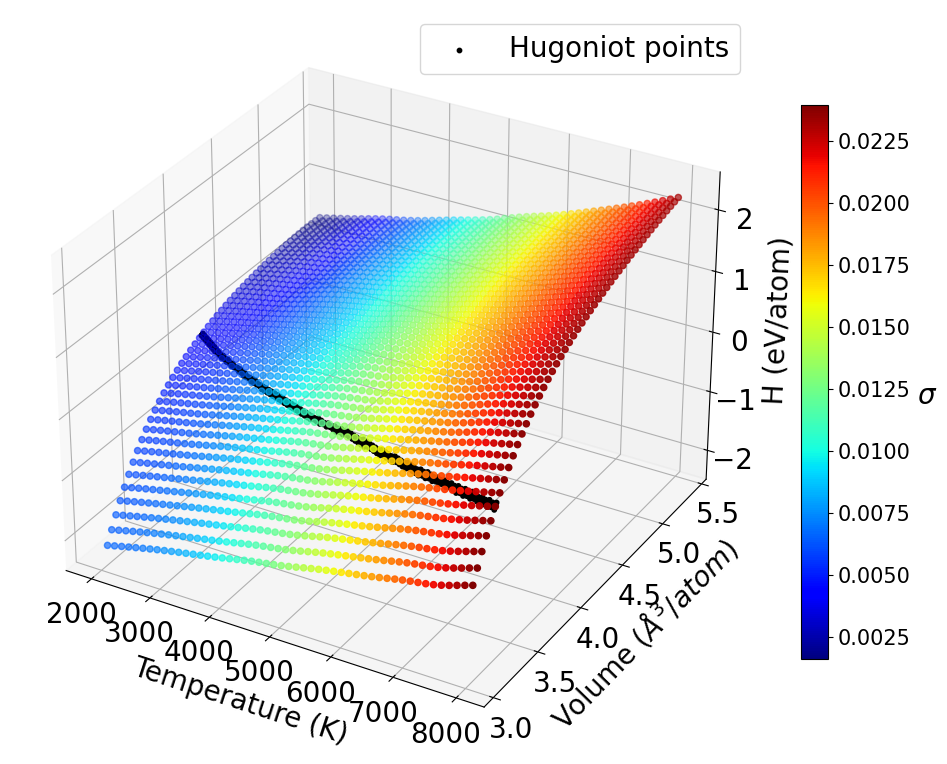

In [311]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(hugon[:,1], hugon[:,0], hugon[:,2], c='k', alpha=1, s=10, label= 'Hugoniot points')
p0 = ax.scatter(X_testP[:,1], X_testP[:,0], meanH_unscaled ,c= H_std, cmap=plt.cm.jet)

matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
ax.set_ylabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_xlabel('Temperature (K)', fontsize=20, labelpad=12)
ax.set_zlabel(r'H (eV/atom)',fontsize=20, labelpad=8)
ax.legend(['Hugoniot points'], loc='upper right', fontsize =20)

cbar = fig.colorbar(p0, ax=ax, shrink=0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad=12)
cbar.ax.tick_params(labelsize=15)

plt.show()

In [312]:
X_H = np.hstack((hugon[:,0].reshape(-1,1), hugon[:,1].reshape(-1,1)))

In [313]:
X_H = scaler.transform(X_H)

In [314]:
y_pred_H, y_std_H = predict(thetaopt, X, y, X_H, n_test, degree)

In [315]:
y11H = y_pred_H[:X_H.shape[0]].reshape(-1,1)
y22H = y_pred_H[X_H.shape[0]:].reshape(-1,1)
y33H = y_std_H[:X_H.shape[0]].reshape(-1,1)
y44H = y_std_H[X_H.shape[0]:].reshape(-1,1)

In [316]:
y_meanH = np.hstack((y11H,y22H))
y_ubH = np.hstack((y11H+y33H, y22H+y44H))
y_lbH = np.hstack((y11H-y33H, y22H-y44H))

In [317]:

y_meanH = scaler1.inverse_transform(y_meanH)
y_ubH = scaler1.inverse_transform(y_ubH)
y_lbH = scaler1.inverse_transform(y_lbH)

In [318]:
y_std1H = y_meanH - y_lbH
y_std2H = y_ubH - y_meanH

In [319]:
meanPH = y_meanH[:,0]
meanEH = y_meanH[:,1]
stdPH =  y_std1H[:,0]
stdEH =  y_std1H[:,1]

In [320]:
X_HH = scaler.inverse_transform(X_H)

/var/folders/vd/pr68_4js7vnf535141p_blwc0000gn/T/ipykernel_17681/1147181476.py:3: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 12


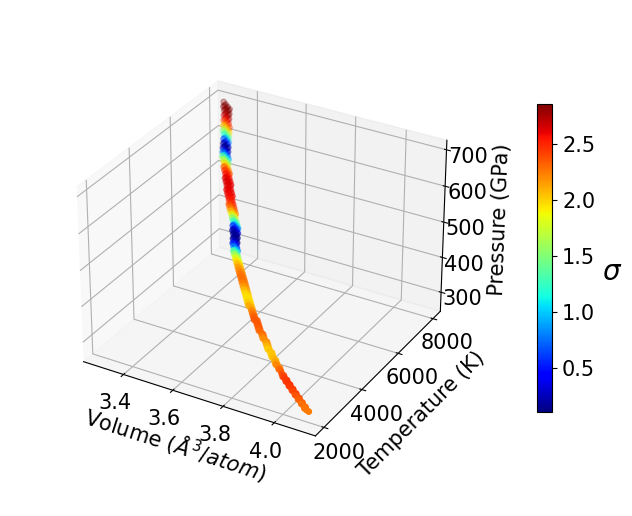

In [321]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.dist = 12
p0 = ax.scatter(X_HH[:,0], X_HH[:,1], meanPH ,c= stdPH, cmap=plt.cm.jet, s=15)
ax.set_yticks([2000,4000,6000,8000])
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
# matplotlib.rc('ztick', labelsize=20)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=15, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=15, labelpad=12)
ax.set_zlabel('Pressure (GPa)',fontsize=15, labelpad=9)
cbar = fig.colorbar(p0, ax=ax, shrink = 0.5)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad= 12)
plt.show()


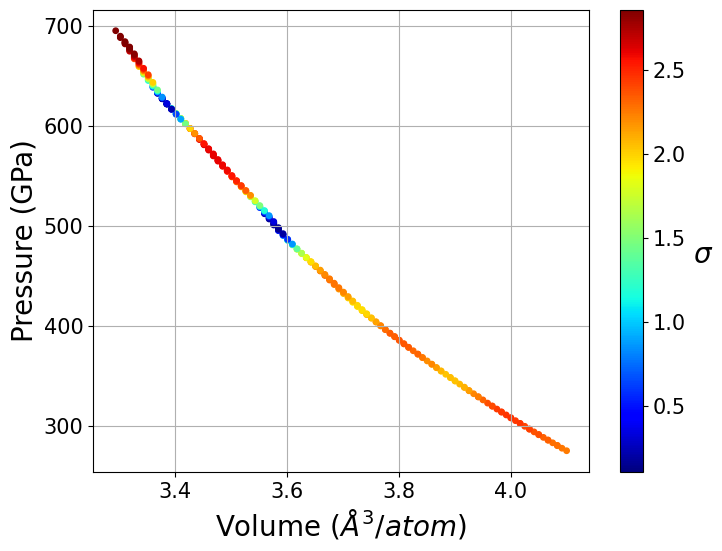

In [322]:
fig = plt.figure(figsize=(8,6))
p0 = plt.scatter(X_HH[:,0], meanPH ,c= stdPH, cmap=plt.cm.jet, s=15)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20 )
plt.ylabel('Pressure (GPa)', fontsize=20)
cbar = fig.colorbar(p0, shrink = 1)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad= 12)
plt.grid()

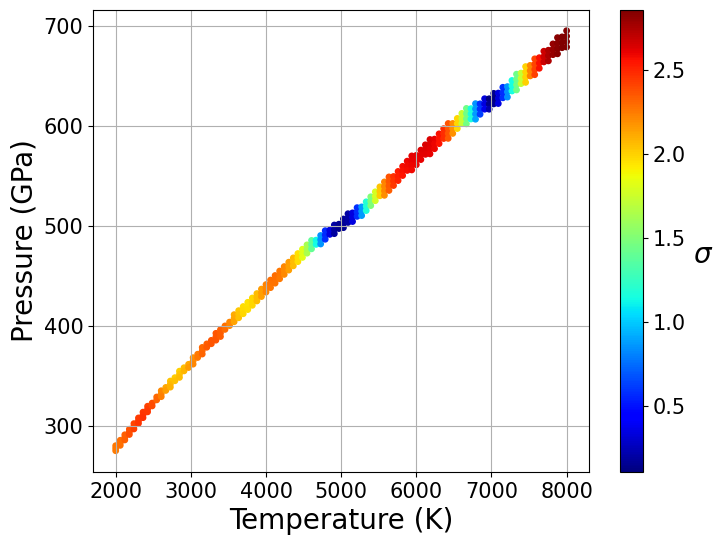

In [323]:
fig = plt.figure(figsize=(8,6))
p0 = plt.scatter(X_HH[:,1], meanPH ,c= stdPH, cmap=plt.cm.jet, s=15)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.xlabel('Temperature (K)', fontsize=20 )
plt.ylabel('Pressure (GPa)', fontsize=20)
cbar = fig.colorbar(p0, shrink = 1)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad= 12)
plt.grid()